# Subsystem QFI and OTOC Heatmaps
This notebook computes and plots:
1. Subsystem QFI heatmap as a function of transverse field `h` and time `t`
2. OTOC heatmap as a function of transverse field `h` and time `t`
3. Bound of the quanutm Lyapunov exponent heatmap as a function of transverse field `h` and time `t`



In [16]:
import numpy as np
import matplotlib.pyplot as plt

from qutip import Qobj, tensor, qeye, sigmax, sigmay, sigmaz, ptrace
from scipy.linalg import lu_factor, lu_solve
from scipy.sparse import csc_matrix
from scipy.sparse.linalg import eigsh

## Core utilities

In [17]:
def crank_nicolson_propagator(H: Qobj, t: float, steps: int = 100) -> Qobj:
    """
    Crank–Nicolson approximation to U(t) = exp(-iHt).
    """
    dt = t / steps
    dim = H.shape[0]
    identity = np.eye(dim, dtype=complex)

    H_dense = H.full()
    A = identity - 1j * (dt / 2) * H_dense
    B = identity + 1j * (dt / 2) * H_dense

    lu, piv = lu_factor(A)
    U_step = lu_solve((lu, piv), B)
    U_total = np.linalg.matrix_power(U_step, steps)

    return Qobj(U_total, dims=H.dims)


def spin_chain_ham(h: float, g: float, J: float, J2: float, N: int) -> Qobj:
    """
    H = -J Σ σ^z_i σ^z_{i+1} + J2 Σ σ^z_i σ^z_{i+2} - h Σ σ^x_i - g Σ σ^z_i
    """
    sx_ops = [tensor([sigmax() if i == j else qeye(2) for i in range(N)]) for j in range(N)]
    sz_ops = [tensor([sigmaz() if i == j else qeye(2) for i in range(N)]) for j in range(N)]

    H = (
        sum(-J * sz_ops[i] * sz_ops[i + 1] for i in range(N - 1))
        + sum(J2 * sz_ops[i] * sz_ops[i + 2] for i in range(N - 2))
        - sum(h * sx_ops[i] for i in range(N))
        - sum(g * sz_ops[i] for i in range(N))
    )
    return H


def ground_state_ket(H: Qobj) -> Qobj:
    """
    Ground state ket from sparse eigensolver.
    """
    H_sparse = csc_matrix(H.full())
    _, evecs = eigsh(H_sparse, k=1, which="SA")
    n_sites = len(H.dims[0])
    psi = Qobj(evecs[:, 0], dims=[H.dims[0], [1] * n_sites])
    return psi.unit()


def pauli_on_site(pauli: str, site: int, N: int) -> Qobj:
    """
    Return a Pauli operator acting on one site of an N-spin chain.
    """
    pauli_map = {
        "x": sigmax(),
        "y": sigmay(),
        "z": sigmaz(),
    }
    op = pauli_map[pauli.lower()]
    return tensor([op if i == site else qeye(2) for i in range(N)])

## QFI computation

In [18]:
def compute_time_qfi_spectral(
    states: list[Qobj],
    tlist: np.ndarray,
    subsystem_index: int = 0,
) -> np.ndarray:
    """
    Subsystem time-QFI from reduced density matrices and finite-difference derivative.
    """
    qfi_values = []

    for i in range(len(tlist)):
        rho_A = ptrace(states[i], [subsystem_index])

        if i == 0:
            rho_A_next = ptrace(states[i + 1], [subsystem_index])
            dt = tlist[i + 1] - tlist[i]
            drho_dt = (rho_A_next - rho_A) / dt
        elif i == len(tlist) - 1:
            rho_A_prev = ptrace(states[i - 1], [subsystem_index])
            dt = tlist[i] - tlist[i - 1]
            drho_dt = (rho_A - rho_A_prev) / dt
        else:
            rho_A_next = ptrace(states[i + 1], [subsystem_index])
            rho_A_prev = ptrace(states[i - 1], [subsystem_index])
            dt = tlist[i + 1] - tlist[i - 1]
            drho_dt = (rho_A_next - rho_A_prev) / dt

        evals, evecs = rho_A.eigenstates()
        qfi_t = 0.0

        for m in range(len(evals)):
            for n in range(len(evals)):
                pm, pn = evals[m], evals[n]
                if pm + pn > 1e-12:
                    d_mn = complex(evecs[m].dag() * drho_dt * evecs[n])
                    qfi_t += (2.0 / (pm + pn)) * abs(d_mn) ** 2

        qfi_values.append(np.real(qfi_t))

    return np.array(qfi_values)


def run_qfi_simulation_for_h(
    *,
    h_value: float,
    N: int,
    J: float,
    J2: float,
    g: float,
    tlist: np.ndarray,
    steps: int,
    subsystem_index: int = 0,
) -> np.ndarray:
    """
    For a fixed h, evolve the perturbed ground state and return subsystem QFI vs time.
    """
    print(f"Running QFI for h = {h_value:.3f}")

    H_full = spin_chain_ham(h=h_value, g=g, J=J, J2=J2, N=N)
    psi0 = ground_state_ket(H_full)
    rho0 = psi0 * psi0.dag()

    perturbation = pauli_on_site("x", site=0, N=N)
    initial_state = perturbation * rho0 * perturbation.dag()

    states = []
    for t in tlist:
        U = crank_nicolson_propagator(H_full, t, steps)
        evolved_state = U * initial_state * U.dag()
        states.append(evolved_state)

    return compute_time_qfi_spectral(states, tlist, subsystem_index=subsystem_index)

## OTOC computation

In [19]:
def compute_otoc_vs_t(
    *,
    H_full: Qobj,
    tlist: np.ndarray,
    steps: int,
    W: Qobj,
    V: Qobj,
) -> np.ndarray:
    """
    OTOC(t) = <psi0| W(t) V W(t) V |psi0>, with W(t)=U†WU.
    """
    psi0 = ground_state_ket(H_full)
    otoc_values = np.zeros(len(tlist), dtype=np.complex128)

    for i, t in enumerate(tlist):
        U = crank_nicolson_propagator(H_full, t, steps)
        W_t = U.dag() * W * U
        otoc_values[i] = complex(psi0.dag() * W_t * V * W_t * V * psi0)

    return otoc_values

## Plotting utility

In [107]:
def plot_heatmap(
    x: np.ndarray,
    y: np.ndarray,
    z: np.ndarray,
    *,
    xlabel: str,
    ylabel: str,
    colorbar_label: str,
    title: str = "",
    ax=None,
):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    assert z.shape == (len(x), len(y)), (
        f"Expected z shape {(len(x), len(y))}, got {z.shape}"
    )

    x_order = np.argsort(x)
    y_order = np.argsort(y)

    x_sorted = x[x_order]
    y_sorted = y[y_order]
    z_sorted = z[np.ix_(x_order, y_order)]

    def _edges(arr):
        arr = np.asarray(arr, dtype=float)
        if arr.size == 1:
            dx = 1.0
            return np.array([arr[0] - dx / 2, arr[0] + dx / 2])

        mid = 0.5 * (arr[1:] + arr[:-1])
        first = arr[0] - (mid[0] - arr[0])
        last = arr[-1] + (arr[-1] - mid[-1])
        return np.concatenate(([first], mid, [last]))

    x_edges = _edges(x_sorted)
    y_edges = _edges(y_sorted)

    finite = np.isfinite(z_sorted)
    if not np.any(finite):
        raise ValueError("Heatmap array contains no finite values.")

    zmin = np.nanmin(z_sorted[finite])
    zmax = np.nanmax(z_sorted[finite])
    norm = Normalize(vmin=zmin, vmax=zmax)

    if ax is None:
        plt.rcParams.update({
            "font.family": "serif",
            "font.size": 9,
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "legend.fontsize": 8,
            "axes.linewidth": 0.8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "xtick.major.size": 3.5,
            "ytick.major.size": 3.5,
        })

        fig, ax = plt.subplots(figsize=(3.35, 2.6), constrained_layout=True)
    else:
        fig = ax.figure

    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        z_sorted.T,
        shading="auto",
        norm=norm,
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Default left-side label and ticks (restored)
    ax.yaxis.set_label_position("left")
    ax.yaxis.tick_left()

    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.tick_params(direction="out")

    cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
    cbar.set_label(colorbar_label)
    cbar.ax.tick_params(direction="out", width=0.8, length=3)

    if title:
        ax.set_title(title)

    return mesh

## Parameters

In [66]:
N = 6
J = 1.0
J2 = 0.0
g = 0.4

h_list = np.linspace(-3.0, 3.0, 60)
tlist = np.linspace(0.0, 2.0, 150)
steps = 800

## Compute and plot subsystem QFI heatmap

In [67]:
qfi_results = {}

for h_val in h_list:
    qfi_results[h_val] = run_qfi_simulation_for_h(
        h_value=h_val,
        N=N,
        J=J,
        J2=J2,
        g=g,
        tlist=tlist,
        steps=steps,
        subsystem_index=0,
    )

QFI_matrix = np.array([qfi_results[h_val] for h_val in h_list])



Running QFI for h = -3.000
Running QFI for h = -2.898
Running QFI for h = -2.797
Running QFI for h = -2.695
Running QFI for h = -2.593
Running QFI for h = -2.492
Running QFI for h = -2.390
Running QFI for h = -2.288
Running QFI for h = -2.186
Running QFI for h = -2.085
Running QFI for h = -1.983
Running QFI for h = -1.881
Running QFI for h = -1.780
Running QFI for h = -1.678
Running QFI for h = -1.576
Running QFI for h = -1.475
Running QFI for h = -1.373
Running QFI for h = -1.271
Running QFI for h = -1.169
Running QFI for h = -1.068
Running QFI for h = -0.966
Running QFI for h = -0.864
Running QFI for h = -0.763
Running QFI for h = -0.661
Running QFI for h = -0.559
Running QFI for h = -0.458
Running QFI for h = -0.356
Running QFI for h = -0.254
Running QFI for h = -0.153
Running QFI for h = -0.051
Running QFI for h = 0.051
Running QFI for h = 0.153
Running QFI for h = 0.254
Running QFI for h = 0.356
Running QFI for h = 0.458
Running QFI for h = 0.559
Running QFI for h = 0.661
Running 

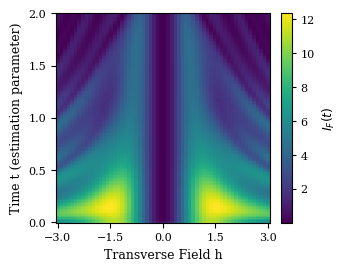

In [108]:
plot_heatmap(
    x=h_list,
    y=tlist,
    z=QFI_matrix,
    xlabel="Transverse Field h",
    ylabel="Time t (estimation parameter)",
    colorbar_label=r"$I_F(t)$",
    title="",
)

## Compute and plot OTOC heatmap

Running OTOC for h = -3.000
Running OTOC for h = -2.898
Running OTOC for h = -2.797
Running OTOC for h = -2.695
Running OTOC for h = -2.593
Running OTOC for h = -2.492
Running OTOC for h = -2.390
Running OTOC for h = -2.288
Running OTOC for h = -2.186
Running OTOC for h = -2.085
Running OTOC for h = -1.983
Running OTOC for h = -1.881
Running OTOC for h = -1.780
Running OTOC for h = -1.678
Running OTOC for h = -1.576
Running OTOC for h = -1.475
Running OTOC for h = -1.373
Running OTOC for h = -1.271
Running OTOC for h = -1.169
Running OTOC for h = -1.068
Running OTOC for h = -0.966
Running OTOC for h = -0.864
Running OTOC for h = -0.763
Running OTOC for h = -0.661
Running OTOC for h = -0.559
Running OTOC for h = -0.458
Running OTOC for h = -0.356
Running OTOC for h = -0.254
Running OTOC for h = -0.153
Running OTOC for h = -0.051
Running OTOC for h = 0.051
Running OTOC for h = 0.153
Running OTOC for h = 0.254
Running OTOC for h = 0.356
Running OTOC for h = 0.458
Running OTOC for h = 0.55

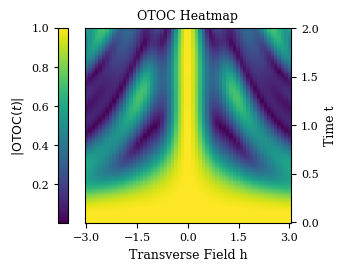

In [71]:
W = pauli_on_site("z", site=1, N=N)
V = pauli_on_site("x", site=0, N=N)

OTOC_matrix = np.zeros((len(h_list), len(tlist)), dtype=np.complex128)

for i, h_val in enumerate(h_list):
    print(f"Running OTOC for h = {h_val:.3f}")
    H_full = spin_chain_ham(h=float(h_val), g=g, J=J, J2=J2, N=N)
    OTOC_matrix[i, :] = compute_otoc_vs_t(
        H_full=H_full,
        tlist=tlist,
        steps=steps,
        W=W,
        V=V,
    )

plot_heatmap(
    x=h_list,
    y=tlist,
    z=np.abs(OTOC_matrix),
    xlabel="Transverse Field h",
    ylabel="Time t",
    colorbar_label=r"$|{\rm OTOC}(t)|$",
    title="OTOC Heatmap",
)


## Extract Lyapunov-like exponent from OTOC
We fit
$$
\ln |\mathrm{OTOC}(t)| = a + bt
$$
over an adaptive time window:
- start at `t_fit_min`
- end at the first sign change of $$\partial_t \ln |\mathrm{OTOC}|$$

Then the extracted Lyapunov-like exponent is
$$
\lambda(h) = -b.
$$

In [45]:
def extract_lyapunov_from_otoc(
    OTOC_matrix: np.ndarray,
    h_list: np.ndarray,
    tlist: np.ndarray,
    *,
    t_fit_min: float = 0.1,
    eps_otoc: float = 1e-14,
):
    """
    Extract a Lyapunov-like exponent λ(h) from OTOC(h,t) by fitting

        ln |OTOC(h,t)| = a(h) + b(h) t

    on an adaptive window [t_fit_min, t_fit_max(h)], where t_fit_max(h)
    is chosen as the first sign change of d/dt ln|OTOC| after t_fit_min.

    Returns
    -------
    lyap : np.ndarray
        λ(h) = -b(h)
    intercepts : np.ndarray
        fitted intercepts a(h)
    r2 : np.ndarray
        coefficient of determination for each fit
    t_fit_max_arr : np.ndarray
        chosen upper fit time for each h
    ln_otoc : np.ndarray
        log-absolute OTOC matrix
    """
    h_list = np.asarray(h_list, dtype=float)
    tlist = np.asarray(tlist, dtype=float)

    abs_otoc = np.clip(np.abs(OTOC_matrix), eps_otoc, None)
    ln_otoc = np.log(abs_otoc)

    lyap = np.full(len(h_list), np.nan, dtype=float)
    intercepts = np.full(len(h_list), np.nan, dtype=float)
    r2 = np.full(len(h_list), np.nan, dtype=float)
    t_fit_max_arr = np.full(len(h_list), np.nan, dtype=float)

    j0 = int(np.searchsorted(tlist, t_fit_min, side="left"))

    for ih in range(len(h_list)):
        y_all = ln_otoc[ih, :]

        # derivative d/dt ln|OTOC|
        dy_dt = np.gradient(y_all, tlist)

        # sign structure
        sign_arr = np.sign(dy_dt)

        # clean exact zeros after j0 by inheriting previous sign
        for j in range(j0 + 1, len(sign_arr)):
            if sign_arr[j] == 0:
                sign_arr[j] = sign_arr[j - 1]

        # first sign change after t_fit_min
        change_idx = None
        for j in range(j0 + 1, len(sign_arr)):
            if sign_arr[j] != sign_arr[j - 1]:
                change_idx = j
                break

        j_end = change_idx if change_idx is not None else (len(tlist) - 1)
        t_fit_max_arr[ih] = tlist[j_end]

        fit_mask = (tlist >= t_fit_min) & (tlist <= tlist[j_end])

        if np.sum(fit_mask) < 3:
            continue

        t_fit = tlist[fit_mask]
        y_fit = y_all[fit_mask]

        # linear fit: y = a + b t
        slope, intercept = np.polyfit(t_fit, y_fit, deg=1)

        intercepts[ih] = intercept
        lyap[ih] = -slope

        y_pred = intercept + slope * t_fit
        ss_res = np.sum((y_fit - y_pred) ** 2)
        ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
        r2[ih] = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return lyap, intercepts, r2, t_fit_max_arr, ln_otoc

In [46]:
lyap, intercepts, r2, t_fit_max_arr, ln_otoc = extract_lyapunov_from_otoc(
    OTOC_matrix=OTOC_matrix,
    h_list=h_list,
    tlist=tlist,
    t_fit_min=0.1,
    eps_otoc=1e-14,
)

## Plot extracted Lyapunov exponent

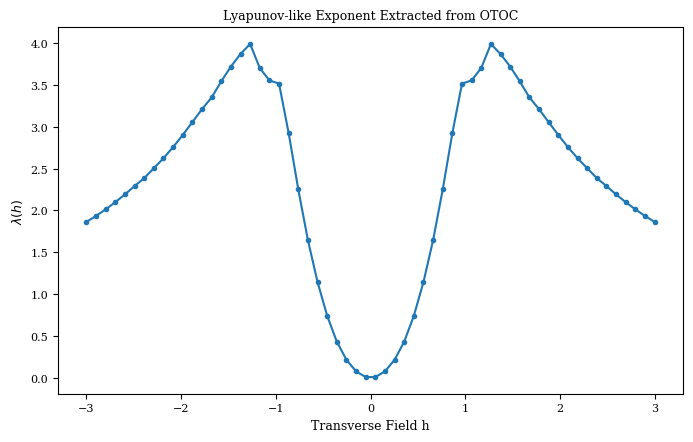

In [47]:
plt.figure(figsize=(7, 4.5))
plt.plot(h_list, lyap, marker="o", markersize=3)
plt.xlabel("Transverse Field h")
plt.ylabel(r"$\lambda(h)$")
plt.title("Lyapunov-like Exponent Extracted from OTOC")
plt.tight_layout()
plt.show()

## Compute Fisher–Lyapunov bound heatmap
Using the already computed `QFI_matrix`, define
$$
\mathcal{B}(h,t)
=
\frac{\left(\int_0^t \sqrt{I_F(h,s)}\, ds\right)^2}{8t}.
$$

In [49]:
from scipy.integrate import cumulative_trapezoid

def compute_fisher_lyapunov_bound(
    QFI_matrix: np.ndarray,
    tlist: np.ndarray,
) -> np.ndarray:
    """
    Compute the Fisher–Lyapunov bound

        B(h,t) = [∫_0^t sqrt(QFI(h,s)) ds]^2 / (8 t)

    with B(h,0)=0.
    """
    qfi_nonneg = np.array(QFI_matrix, dtype=float).copy()
    qfi_nonneg[qfi_nonneg < 0] = 0.0

    B = np.zeros_like(qfi_nonneg, dtype=float)

    for ih in range(qfi_nonneg.shape[0]):
        sqrt_qfi = np.sqrt(qfi_nonneg[ih, :])
        Z_t = cumulative_trapezoid(sqrt_qfi, tlist, initial=0.0)

        B_row = np.zeros_like(tlist, dtype=float)
        B_row[1:] = (Z_t[1:] ** 2) / (8.0 * tlist[1:])
        B[ih, :] = B_row

    return B

In [50]:
B = compute_fisher_lyapunov_bound(QFI_matrix=QFI_matrix, tlist=tlist)

## Final heatmap of the Fisher–Lyapunov bound

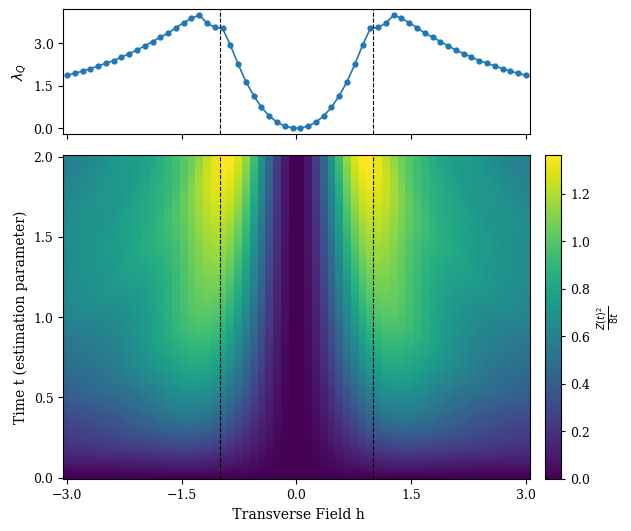

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

h = np.asarray(h_list, dtype=float)
lam = np.asarray(lyap, dtype=float)

h_ord = np.argsort(h)
h = h[h_ord]
lam = lam[h_ord]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
})

fig = plt.figure(figsize=(6.2, 5.2), constrained_layout=True)
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 2.6], hspace=0.05)

ax_top = fig.add_subplot(gs[0, 0])
ax_bot = fig.add_subplot(gs[1, 0], sharex=ax_top)

# Top panel
ax_top.plot(h, lam, linewidth=1.2)
ax_top.scatter(h, lam, s=12)
ax_top.set_ylabel(r"$\lambda_Q$")
#ax_top.yaxis.set_label_position("right")
#ax_top.yaxis.tick_right()
ax_top.yaxis.set_major_locator(MaxNLocator(nbins=4))
ax_top.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax_top.tick_params(direction="out")
plt.setp(ax_top.get_xticklabels(), visible=False)

# Bottom panel via reusable helper
plot_heatmap(
    x=h_list,
    y=tlist,
    z=B,
    xlabel=" Transverse Field h",
    ylabel="Time t (estimation parameter)",
    colorbar_label=r"$\frac{Z(t)^2}{8t}$",
    title="",
    ax=ax_bot,
)

# Optional critical lines
for hc in [-1.0, 1.0]:
    ax_top.axvline(hc, linestyle="--", linewidth=0.8, color="black")
    ax_bot.axvline(hc, linestyle="--", linewidth=0.8, color="black")
    
#plt.savefig("lyapunov and avg-qfi.pdf")

plt.show()